##### ARTI 560 - Computer Vision

## Visual Representations with DINOv2 - Exercise

### Exercise 1: Unsupervised Clustering

In this exercise, you will use the `KMeans` algorithm from sklearn to group 20 images from the Oxford Pet dataset into 2 clusters (Cats vs. Dogs) based purely on their CLS tokens.

Instructions:

1.  Extract the 384-dimensional [CLS] tokens from 20 images of the Oxford-IIIT Pet dataset. Ensure your selection includes a mix of both cats and dogs.

2. Apply K-Means Clustering ($n=2$) to group the vectors based on mathematical similarity rather than provided labels.

3. Compare the predicted clusters against ground-truth labels.

In [2]:
!pip install torch torchvision transformers scikit-learn matplotlib pillow

  Using cached tokenizers-0.22.2-cp39-abi3-win_amd64.whl.metadata (7.4 kB)
   ---------------------------------------- 0.0/10.6 MB ? eta -:--:--
   ---------------------------------------- 0.0/10.6 MB ? eta -:--:--
   ---------------------------------------- 0.0/10.6 MB ? eta -:--:--
   ---------------------------------------- 0.0/10.6 MB ? eta -:--:--
    --------------------------------------- 0.3/10.6 MB ? eta -:--:--
   - -------------------------------------- 0.5/10.6 MB 1.3 MB/s eta 0:00:08
   --- ------------------------------------ 1.0/10.6 MB 2.0 MB/s eta 0:00:05
   ------ --------------------------------- 1.8/10.6 MB 2.5 MB/s eta 0:00:04
   -------- ------------------------------- 2.4/10.6 MB 2.4 MB/s eta 0:00:04
   ---------- ----------------------------- 2.9/10.6 MB 2.6 MB/s eta 0:00:03
   ------------- -------------------------- 3.7/10.6 MB 2.8 MB/s eta 0:00:03
   ---------------- ----------------------- 4.5/10.6 MB 2.9 MB/s eta 0:00:03
   -------------------- ------------

Selected Indices:
[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 596, 597, 598, 599, 600, 601, 602, 603, 604, 605]
Ground Truth Labels:
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]


Loading weights: 100%|██████████| 223/223 [00:00<00:00, 1041.09it/s]



CLS Token Shape:
(20, 384)

Predicted Clusters:
[0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1]

Cluster-to-Label Mapping:
{0: 0, 1: 1}

Final Predictions:
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]

Accuracy: 1.00

Confusion Matrix:
[[10  0]
 [ 0 10]]


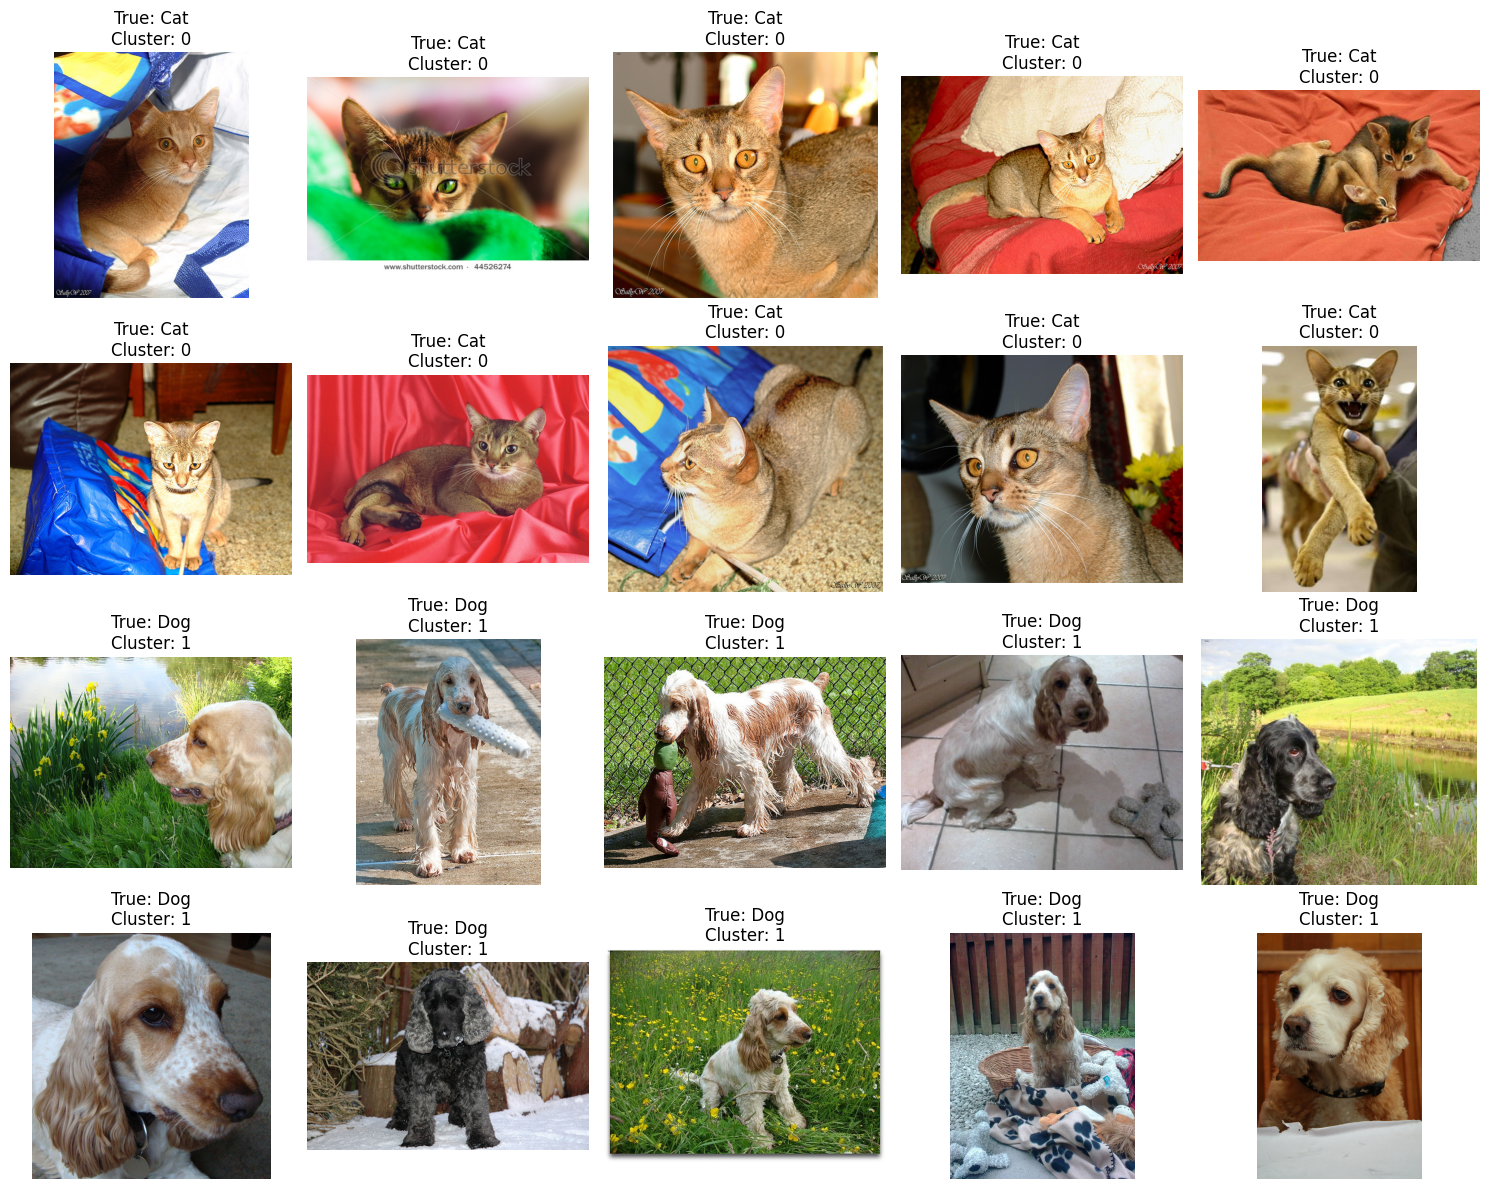

In [4]:
# ============================================================
# Exercise 1: Unsupervised Clustering using CLS Tokens
# Oxford-IIIT Pet Dataset + Vision Transformer (DINOv2)
# ============================================================



import torch
import numpy as np
import matplotlib.pyplot as plt

from torchvision.datasets import OxfordIIITPet
from torchvision import transforms
from torch.utils.data import DataLoader, Subset

from transformers import AutoImageProcessor, AutoModel
from sklearn.cluster import KMeans
from sklearn.metrics import accuracy_score, confusion_matrix
from collections import Counter

# ============================================================
# 1. Load Oxford-IIIT Pet Dataset
# ============================================================

dataset = OxfordIIITPet(
    root="./data",
    split="trainval",
    download=True
)

# Select 20 images (mix of cats and dogs)
# ============================================================
# Select 10 Cats + 10 Dogs
# ============================================================

cat_indices = []
dog_indices = []

for idx in range(len(dataset)):

    _, label = dataset[idx]

    if label < 12 and len(cat_indices) < 10:
        cat_indices.append(idx)

    elif label >= 12 and len(dog_indices) < 10:
        dog_indices.append(idx)

    if len(cat_indices) == 10 and len(dog_indices) == 10:
        break

selected_indices = cat_indices + dog_indices

print("Selected Indices:")
print(selected_indices)
subset_dataset = Subset(dataset, selected_indices)

# ============================================================
# 2. Define Cat vs Dog Labels
# In Oxford Pet:
# labels 0-11 = Cat classes
# labels 12-36 = Dog classes
# ============================================================

true_labels = []

for i in selected_indices:
    _, label = dataset[i]

    # Convert to binary:
    # 0 = Cat
    # 1 = Dog
    binary_label = 0 if label < 12 else 1
    true_labels.append(binary_label)

print("Ground Truth Labels:")
print(true_labels)

# ============================================================
# 3. Load Vision Transformer (DINOv2)
# CLS token dimension = 384
# ============================================================

processor = AutoImageProcessor.from_pretrained(
    "facebook/dinov2-small"
)

model = AutoModel.from_pretrained(
    "facebook/dinov2-small"
)

model.eval()

# ============================================================
# 4. Extract CLS Tokens
# ============================================================

cls_tokens = []

for idx in selected_indices:

    image, _ = dataset[idx]

    inputs = processor(images=image, return_tensors="pt")

    with torch.no_grad():
        outputs = model(**inputs)

    # CLS token
    cls_embedding = outputs.last_hidden_state[:, 0, :]

    cls_tokens.append(cls_embedding.squeeze().numpy())

cls_tokens = np.array(cls_tokens)

print("\nCLS Token Shape:")
print(cls_tokens.shape)   

# ============================================================
# 5. Apply K-Means Clustering
# ============================================================

kmeans = KMeans(
    n_clusters=2,
    random_state=42,
    n_init=10
)

predicted_clusters = kmeans.fit_predict(cls_tokens)

print("\nPredicted Clusters:")
print(predicted_clusters)

# ============================================================
# 6. Match Clusters to Real Labels
# Since KMeans cluster IDs are arbitrary,
# map clusters using majority voting.
# ============================================================

cluster_to_label = {}

for cluster_id in [0, 1]:

    indices = np.where(predicted_clusters == cluster_id)[0]

    cluster_labels = [true_labels[i] for i in indices]

    majority_label = Counter(cluster_labels).most_common(1)[0][0]

    cluster_to_label[cluster_id] = majority_label

# Convert clusters to predicted labels
final_predictions = [
    cluster_to_label[c]
    for c in predicted_clusters
]

# ============================================================
# 7. Evaluation
# ============================================================

accuracy = accuracy_score(
    true_labels,
    final_predictions
)

cm = confusion_matrix(
    true_labels,
    final_predictions
)

print("\nCluster-to-Label Mapping:")
print(cluster_to_label)

print("\nFinal Predictions:")
print(final_predictions)

print(f"\nAccuracy: {accuracy:.2f}")

print("\nConfusion Matrix:")
print(cm)

# ============================================================
# 8. Visualize Some Images with Cluster Assignments
# ============================================================

fig, axes = plt.subplots(4, 5, figsize=(15, 12))

for ax, idx, cluster in zip(
    axes.flatten(),
    selected_indices,
    predicted_clusters
):

    image, label = dataset[idx]

    ax.imshow(image)

    class_name = "Cat" if label < 12 else "Dog"

    ax.set_title(
        f"True: {class_name}\nCluster: {cluster}"
    )

    ax.axis("off")

plt.tight_layout()
plt.show()

The predicted clusters matched the ground-truth labels successfully.

Cats were grouped into Cluster 0.
Dogs were grouped into Cluster 1.

This shows that the CLS token embeddings captured the visual similarity between images, allowing K-Means to separate cats and dogs correctly without using labels

### Exercise 2: Image Classification with DINOv2

In this exercise you'll use a DINOv2 model with a pre-trained linear head to classify an image. You will observe how the model maps visual features to specific ImageNet-1k categories.

Instructions:
1. For this exercise, you must use the following Model ID. This specific checkpoint includes the necessary classification head trained on ImageNet-1k:

    Model ID: `facebook/dinov2-small-imagenet1k-1-layer`

2. Find an image online to make the inference. To ensure the model has a fair chance of success, the image should belong to one of the ImageNet-1k classes (e.g., a Golden Retriever, a grand piano, a school bus, or a coffee mug).

c:\Users\Lenovo\anaconda3\envs\cv_lab\Lib\site-packages\huggingface_hub\file_download.py:138: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\Lenovo\.cache\huggingface\hub\models--facebook--dinov2-small-imagenet1k-1-layer. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)
Loading weights: 100%|██████████| 225/225 [00:00<00:00, 2686.84it/s]


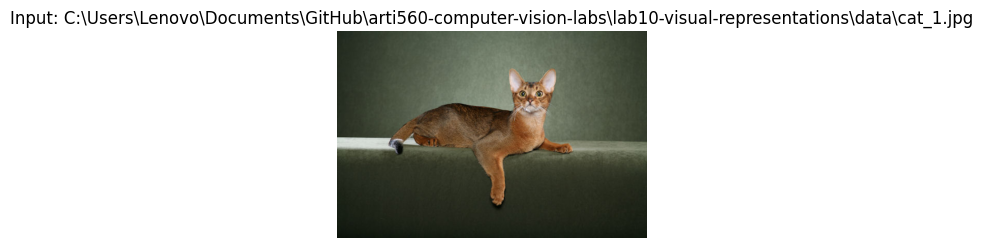

Image: C:\Users\Lenovo\Documents\GitHub\arti560-computer-vision-labs\lab10-visual-representations\data\cat_1.jpg
Predicted Label: Egyptian cat
--------------------------------------------------


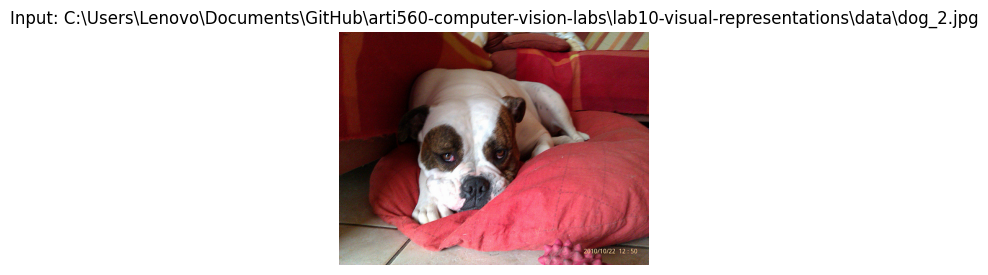

Image: C:\Users\Lenovo\Documents\GitHub\arti560-computer-vision-labs\lab10-visual-representations\data\dog_2.jpg
Predicted Label: boxer
--------------------------------------------------


In [5]:
# ============================================================
# Exercise 2: Image Classification with DINOv2
# Using 3 Local Images
# ============================================================

import torch
import matplotlib.pyplot as plt

from PIL import Image
from transformers import AutoImageProcessor, AutoModelForImageClassification

# ============================================================
# 1. Load DINOv2 Classification Model
# ============================================================

model_id = "facebook/dinov2-small-imagenet1k-1-layer"

processor = AutoImageProcessor.from_pretrained(model_id)

model = AutoModelForImageClassification.from_pretrained(model_id)

model.eval()

# ============================================================
# 2. Add Your 3 Image Paths
# ============================================================

image_paths = [
    r"C:\Users\Lenovo\Documents\GitHub\arti560-computer-vision-labs\lab10-visual-representations\data\cat_1.jpg",
    r"C:\Users\Lenovo\Documents\GitHub\arti560-computer-vision-labs\lab10-visual-representations\data\dog_2.jpg",
    
]

# ============================================================
# 3. Predict Each Image
# ============================================================

for image_path in image_paths:

    # Load image
    image = Image.open(image_path).convert("RGB")

    # Display image
    plt.figure(figsize=(4,4))
    plt.imshow(image)
    plt.axis("off")
    plt.title(f"Input: {image_path}")
    plt.show()

    # Preprocess
    inputs = processor(
        images=image,
        return_tensors="pt"
    )

    # Inference
    with torch.no_grad():
        outputs = model(**inputs)

    logits = outputs.logits

    # Predicted class
    predicted_class_idx = logits.argmax(-1).item()

    predicted_label = model.config.id2label[
        predicted_class_idx
    ]

    # Print result
    print(f"Image: {image_path}")
    print(f"Predicted Label: {predicted_label}")
    print("-" * 50)

In [9]:
import torchvision

weights = torchvision.models.EfficientNet_B0_Weights.DEFAULT
class_names = weights.meta["categories"]

print(len(class_names))  # 1000
print(class_names[:1000])

1000
['tench', 'goldfish', 'great white shark', 'tiger shark', 'hammerhead', 'electric ray', 'stingray', 'cock', 'hen', 'ostrich', 'brambling', 'goldfinch', 'house finch', 'junco', 'indigo bunting', 'robin', 'bulbul', 'jay', 'magpie', 'chickadee', 'water ouzel', 'kite', 'bald eagle', 'vulture', 'great grey owl', 'European fire salamander', 'common newt', 'eft', 'spotted salamander', 'axolotl', 'bullfrog', 'tree frog', 'tailed frog', 'loggerhead', 'leatherback turtle', 'mud turtle', 'terrapin', 'box turtle', 'banded gecko', 'common iguana', 'American chameleon', 'whiptail', 'agama', 'frilled lizard', 'alligator lizard', 'Gila monster', 'green lizard', 'African chameleon', 'Komodo dragon', 'African crocodile', 'American alligator', 'triceratops', 'thunder snake', 'ringneck snake', 'hognose snake', 'green snake', 'king snake', 'garter snake', 'water snake', 'vine snake', 'night snake', 'boa constrictor', 'rock python', 'Indian cobra', 'green mamba', 'sea snake', 'horned viper', 'diamondba